In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

dir_ = '../node-server/data/07-07-2025/' 
df = pd.read_csv(dir_ + 'tendis_20250707_103559.csv')
df.head(3)

,milliseconds,RRL1A:IST:2,RRL1ATEMP:IST:2,EICV:IST:2,RRL1A:I4:2,RRL1WTO:IST:2,RRL1WTU:IST:2,MNC3:IST:2,RRL1A:I3:2,EICI:IST:2,INT,scan
0,178,4574.1,42.1,133.315,0.000009,28.5,28.1,1701.4,0.000008,4.21912,0,0
1,278,4574.1,42.1,133.312,0.000009,28.5,28.1,1701.4,0.000008,4.18860,0,0
2,478,4574.1,42.1,133.312,0.000009,28.5,28.1,1702.5,0.000008,4.18860,0,0


In [13]:
# Calculate difference from previous row
df['diff'] = df['RRL1A:IST:2'].diff()
# Label direction
df['flag'] = np.sign(df['diff']).fillna(0).astype(int)
df.head(2)

,milliseconds,RRL1A:IST:2,RRL1ATEMP:IST:2,EICV:IST:2,RRL1A:I4:2,RRL1WTO:IST:2,RRL1WTU:IST:2,MNC3:IST:2,RRL1A:I3:2,EICI:IST:2,INT,scan,diff,flag
0,178,4574.1,42.1,133.315,0.000009,28.5,28.1,1701.4,0.000008,4.21912,0,0,NaN,0
1,278,4574.1,42.1,133.312,0.000009,28.5,28.1,1701.4,0.000008,4.18860,0,0,0.0,0


In [14]:
def find_one_intervals(binary_list):
    intervals = []
    start = None

    for i, bit in enumerate(binary_list):
        if bit == 1:
            if start is None:
                start = i
        elif start is not None:
            intervals.append((start, i - 1))
            start = None

    # Check if the list ends with a 1-sequence
    if start is not None:
        intervals.append((start, len(binary_list) - 1))

    return intervals

list_indicies =  find_one_intervals(df['INT'])

In [15]:
positions_inter = {'A':[],'B':[]}
for i in list_indicies:
    if df['flag'][i[0]]==1 and df['RRL1A:IST:2'][i[0]]< 4500 :
        positions_inter['A'].append(df['RRL1A:IST:2'][i[0]])
        
    if df['flag'][i[0]]==-1 and df['RRL1A:IST:2'][i[0]]< 4500:
        positions_inter['B'].append(df['RRL1A:IST:2'][i[0]])
    
#positions_inter

In [16]:
df = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in positions_inter.items() ]))
df

,A,B
0,3297.19,3542.42
1,3824.87,2200.53
2,4361.49,4093.67
3,3202.19,2605.84
4,2150.56,2235.95
5,3380.32,3357.37
6,3672.18,2120.93
7,3798.31,3347.13
8,3742.42,2107.11
9,3882.72,3911.38


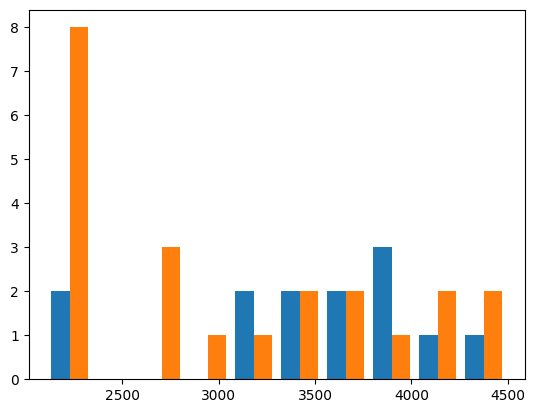

In [17]:
plt.hist(df)
plt.show()